### Imports

In [1]:
!pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to /tmp/pip-req-build-uvcgipzi
  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git /tmp/pip-req-build-uvcgipzi
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Preparing metadata (setup.py) ... done


In [2]:
!pip install opencv-python pycocotools matplotlib onnxruntime onnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.0/16.0 MB 94.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 5.4 MB/s eta 0:00:00


In [ ]:
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

### Initializing SAM

In [3]:
import os
import h5py
import numpy as np
import cv2 
import matplotlib.pyplot as plt

# Import SAM modules (make sure you have the Segment Anything repository cloned/installed)
from segment_anything import sam_model_registry, SamPredictor

# Set up the SAM model checkpoint and type.
# Make sure to update the path to the downloaded checkpoint file.
sam_checkpoint = '/kaggle/working/sam_vit_h_4b8939.pth'  # <-- Update this path!
model_type = 'vit_h'  # Options include 'vit_h', 'vit_l', or 'vit_b'

# Initialize the SAM model and predictor
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
predictor = SamPredictor(sam)

print("SAM model and predictor initialized.")

/usr/local/lib/python3.10/dist-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


SAM model and predictor initialized.


#### Helper functions for loading data and processing

In [10]:
def load_mat_file(mat_file_path):
    """
    Load a MATLAB v7.3 file using h5py and return the content as a dictionary.
    """
    data = {}
    with h5py.File(mat_file_path, 'r') as f:
        # In our MATLAB file, the main struct is stored under the key 'cjdata'
        cjdata = f['cjdata']
        for key in cjdata.keys():
            data[key] = np.array(cjdata[key])
    return data

def get_image_from_data(data):
    """
    Extracts the image from the loaded data, applies intensity normalization, 
    contrast enhancement using CLAHE, and converts the image to a 3-channel RGB format
    using a colormap.
    """
    image = data['image']
    # If the image is 2D (grayscale) or has a singleton channel dimension:
    if image.ndim == 2 or (image.ndim == 3 and image.shape[-1] == 1):
        if image.ndim == 3:
            image = image.squeeze(axis=-1)
        # Normalize image intensities to [0, 255]
        image = image.astype(np.float32)
        image = 255 * (image - image.min()) / (image.max() - image.min() + 1e-8)
        image = image.astype(np.uint8)
        # Apply CLAHE for contrast enhancement
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        image_clahe = clahe.apply(image)
        # Convert the enhanced image to RGB using a colormap
        image_rgb = cv2.applyColorMap(image_clahe, cv2.COLORMAP_JET)
    elif image.ndim == 3 and image.shape[-1] == 3:
        # Assume the image is already 3-channel; you may still want to normalize it
        image = image.astype(np.float32)
        image = 255 * (image - image.min()) / (image.max() - image.min() + 1e-8)
        image_rgb = image.astype(np.uint8)
    else:
        raise ValueError("Unsupported image dimensions")
    return image_rgb

def get_tumor_mask_from_data(data):
    """
    Extract the ground truth tumor mask from the loaded data.
    """
    tumor_mask = data['tumorMask']
    # Threshold in case the mask is not strictly binary.
    tumor_mask = (tumor_mask > 0.5).astype(np.uint8)
    return tumor_mask

def get_bbox_from_mask(mask):
    """
    Compute a bounding box around the tumor region in the binary mask.
    Returns [x_min, y_min, width, height] as required by SAM.
    """
    coords = np.argwhere(mask)
    if coords.size == 0:
        return None
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)
    return [x_min, y_min, x_max - x_min, y_max - y_min]

def get_points_from_border(data):
    """
    Extract point prompts from the tumor border, if available.
    Assumes tumorBorder is stored as a vector: [x1, y1, x2, y2, ...].
    Returns an array of shape (N, 2) containing (x, y) coordinates.
    """
    if 'tumorBorder' in data:
        points = np.array(data['tumorBorder']).flatten()
        if points.size % 2 != 0:
            print("Warning: tumorBorder does not contain an even number of values.")
            return None
        points = points.reshape(-1, 2)
        return points
    return None


def dice_coefficient(gt, pred, smooth=1e-6):
    """
    Compute the Dice coefficient between two binary masks.
    """
    gt = gt.astype(np.float32)
    pred = pred.astype(np.float32)
    intersection = np.sum(gt * pred)
    return (2. * intersection + smooth) / (np.sum(gt) + np.sum(pred) + smooth)


def visualize_segmentation(image, gt_mask, pred_mask):
    """
    Visualize the original image, ground truth mask, and SAM-predicted mask side by side.
    """
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(image)
    axs[0].set_title("Original Image")
    axs[0].axis('off')
    axs[1].imshow(gt_mask, cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[1].axis('off')
    axs[2].imshow(pred_mask, cmap='gray')
    axs[2].set_title("SAM Predicted Mask")
    axs[2].axis('off')
    plt.tight_layout()
    plt.show()


#### List all .mat files in the dataset directory

In [9]:
# Update this path to point to the folder containing your .mat files.
data_dir = '/kaggle/input/brain-tumor/brain_tumor'
mat_files = [os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith('.mat')]

print(f"Found {len(mat_files)} .mat files in {data_dir}.")

Found 100 .mat files in /kaggle/input/brain-tumor/brain_tumor.


#### Segmentation and results loop

Starting segmentation on 100 files...


Processing file 1/100: 2912.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [239, 294, 82, 101]
  [4/7] Extracting tumor border points (if available)...
  Found 15 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.7221603 0.7656629 0.8392408]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 2912.mat - Dice Score: 0.0000
  Ground Truth Mask -> min: 0, max: 1, sum: 2695
  Predicted Mask  -> min: 0, max: 1, sum: 4668
  Time taken for this file: 31.90 seconds
--------------------------------------------------------------------------------


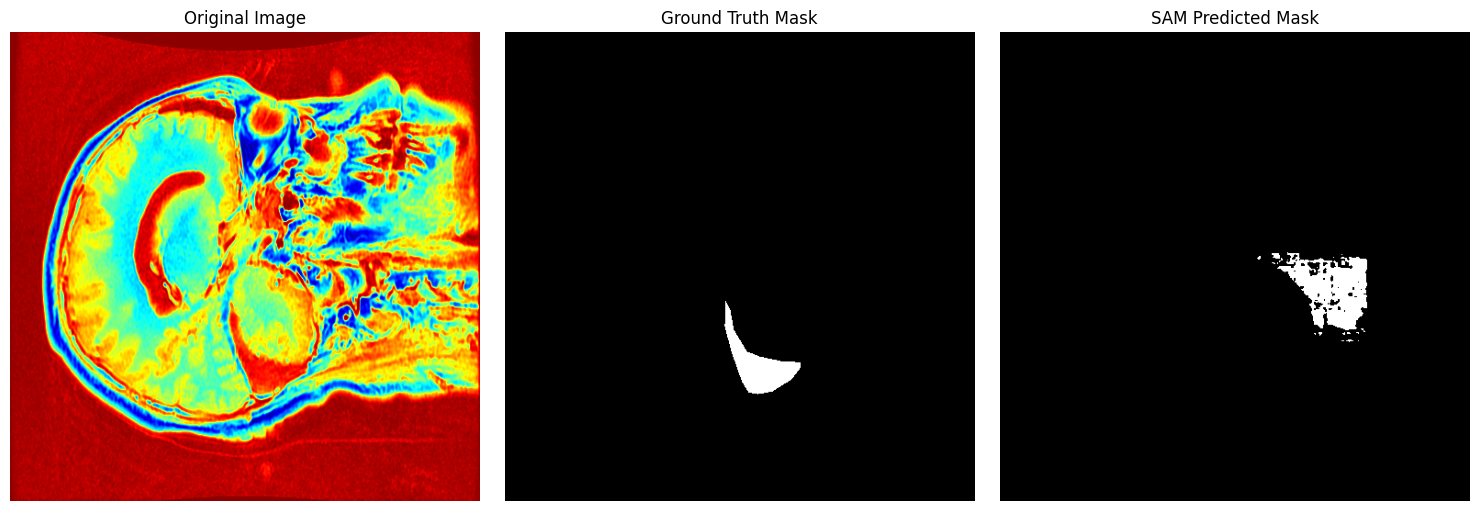

  Saved result image: /kaggle/working/result_001.png

Processing file 2/100: 2011.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [130, 157, 97, 95]
  [4/7] Extracting tumor border points (if available)...
  Found 22 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.5957406 0.8078104 0.8292794]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 2011.mat - Dice Score: 0.5918
  Ground Truth Mask -> min: 0, max: 1, sum: 5619
  Predicted Mask  -> min: 0, max: 1, sum: 10697
  Time taken for this file: 31.99 seconds
--------------------------------------------------------------------------------

Processing file 3/100: 3027.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [202, 162, 63, 92]
  [4/7] Ex

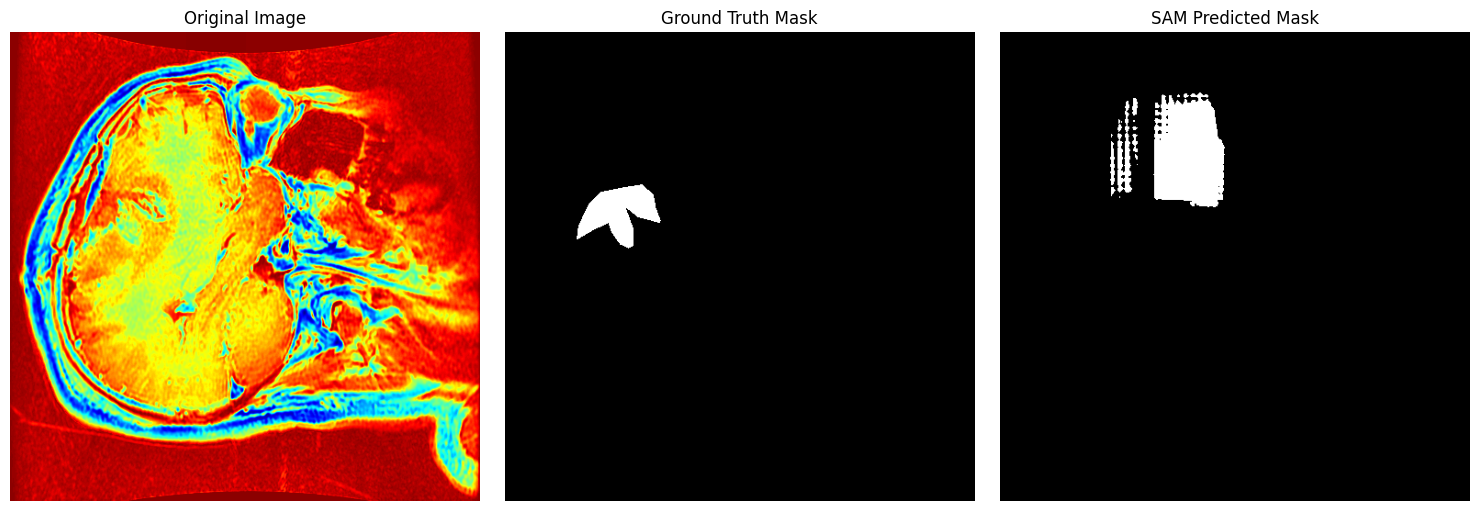

  Saved result image: /kaggle/working/result_021.png

Processing file 22/100: 145.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [151, 264, 128, 131]
  [4/7] Extracting tumor border points (if available)...
  Found 28 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.569541   0.72989523 0.7866131 ]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 145.mat - Dice Score: 0.0000
  Ground Truth Mask -> min: 0, max: 1, sum: 10996
  Predicted Mask  -> min: 0, max: 1, sum: 12487
  Time taken for this file: 32.27 seconds
--------------------------------------------------------------------------------

Processing file 23/100: 655.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [159, 312, 59, 53]
  [4/

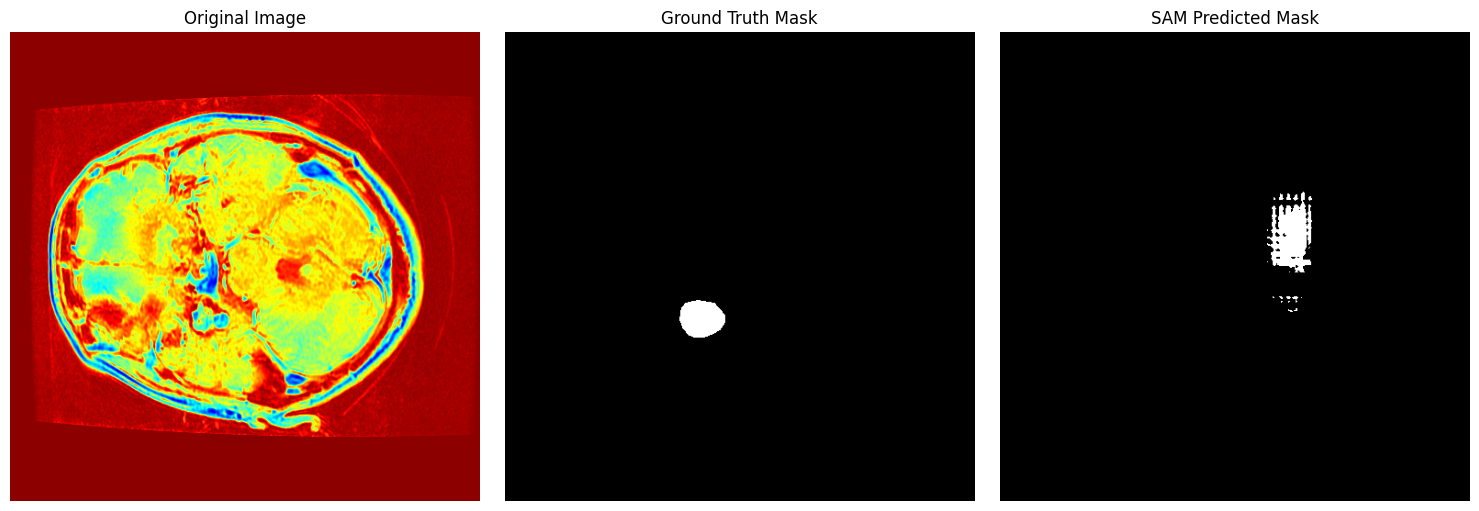

  Saved result image: /kaggle/working/result_041.png

Processing file 42/100: 1697.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [289, 188, 42, 40]
  [4/7] Extracting tumor border points (if available)...
  Found 13 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.6044863  0.83083355 0.8504816 ]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 1697.mat - Dice Score: 0.0000
  Ground Truth Mask -> min: 0, max: 1, sum: 1381
  Predicted Mask  -> min: 0, max: 1, sum: 540
  Time taken for this file: 32.89 seconds
--------------------------------------------------------------------------------

Processing file 43/100: 1113.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [279, 224, 42, 58]
  [4/7]

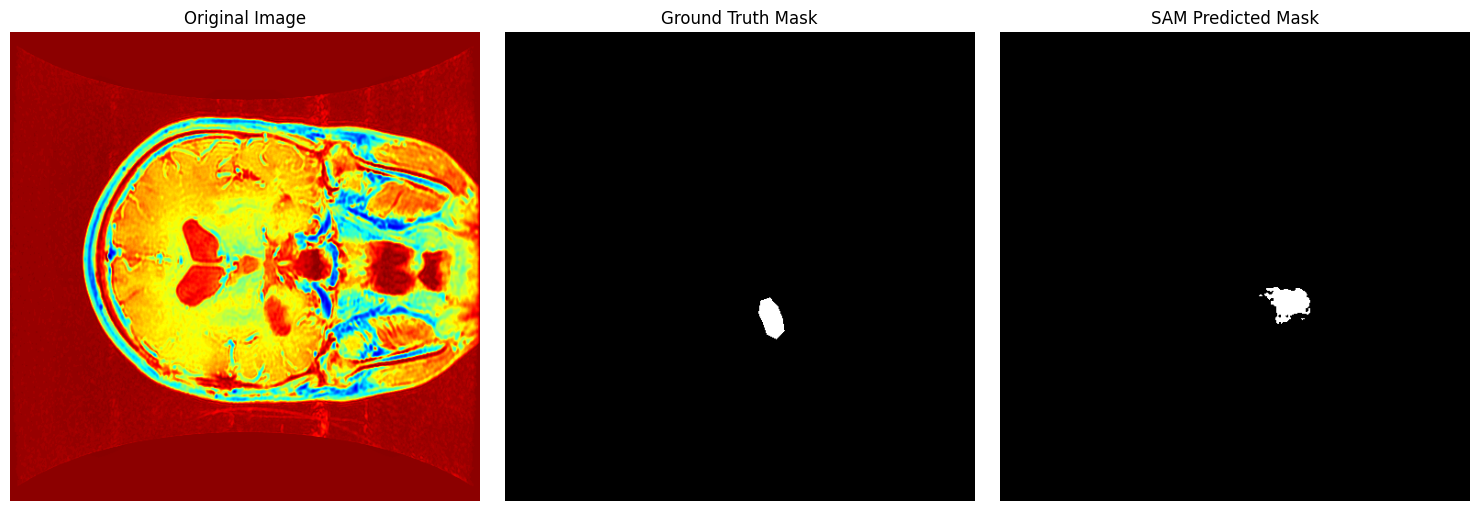

  Saved result image: /kaggle/working/result_061.png

Processing file 62/100: 900.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [73, 195, 132, 161]
  [4/7] Extracting tumor border points (if available)...
  Found 51 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.56052554 0.5997151  0.7049453 ]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 900.mat - Dice Score: 0.0018
  Ground Truth Mask -> min: 0, max: 1, sum: 11541
  Predicted Mask  -> min: 0, max: 1, sum: 18754
  Time taken for this file: 32.78 seconds
--------------------------------------------------------------------------------

Processing file 63/100: 1080.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [242, 218, 90, 70]
  [4/

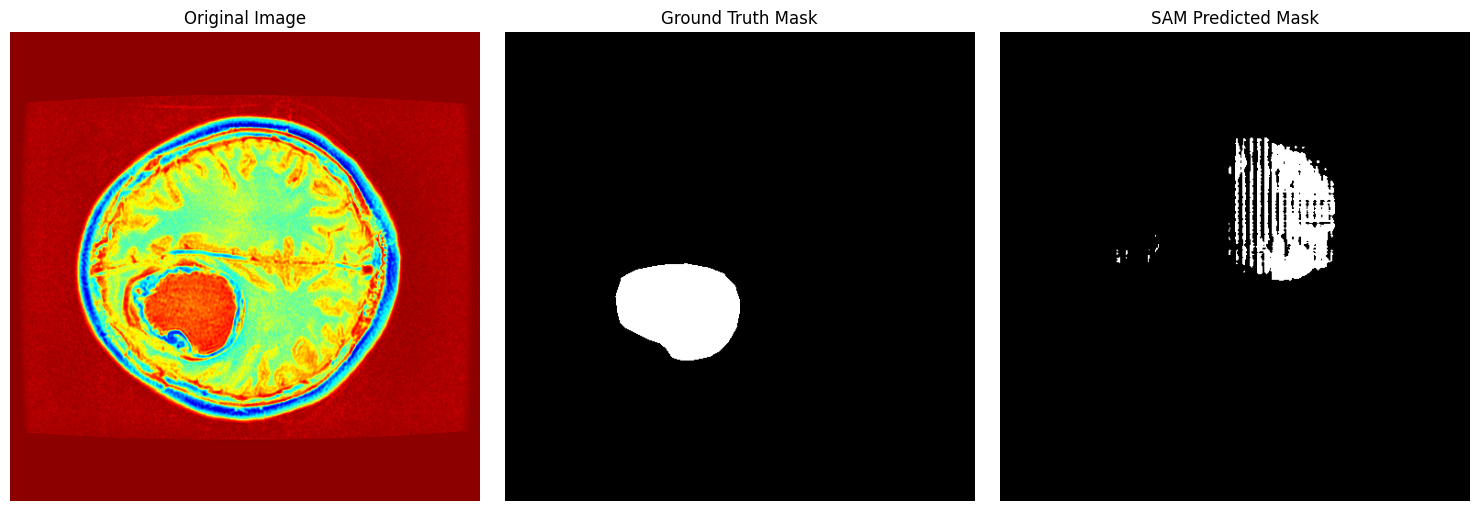

  Saved result image: /kaggle/working/result_081.png

Processing file 82/100: 412.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [90, 197, 61, 61]
  [4/7] Extracting tumor border points (if available)...
  Found 31 border points.
  [5/7] Setting image for SAM predictor...
  [6/7] Running SAM prediction...
  SAM prediction scores: [0.5140519  0.5573452  0.64578426]
  Number of candidate masks returned: 3
  [7/7] Computing Dice coefficient...
  File: 412.mat - Dice Score: 0.0461
  Ground Truth Mask -> min: 0, max: 1, sum: 3265
  Predicted Mask  -> min: 0, max: 1, sum: 15591
  Time taken for this file: 31.81 seconds
--------------------------------------------------------------------------------

Processing file 83/100: 294.mat
  [1/7] Loading MATLAB file...
  [2/7] Extracting image and tumor mask...
  [3/7] Computing bounding box from tumor mask...
  Bounding box: [165, 178, 61, 58]
  [4/7] E

NameError: name 'pd' is not defined

In [13]:
import time
import os

dice_scores = []
total_files = len(mat_files)

print(f"Starting segmentation on {total_files} files...\n")

for idx, mat_file in enumerate(mat_files):
    print(f"\nProcessing file {idx+1}/{total_files}: {os.path.basename(mat_file)}")
    start_time = time.time()
    
    # Load the MATLAB file.
    print("  [1/7] Loading MATLAB file...")
    try:
        data = load_mat_file(mat_file)
    except Exception as e:
        print(f"  Error loading {mat_file}: {e}")
        continue

    # Extract the image and ground-truth tumor mask.
    print("  [2/7] Extracting image and tumor mask...")
    image = get_image_from_data(data)
    gt_mask = get_tumor_mask_from_data(data)
    
    # Compute a bounding box prompt from the ground truth mask.
    print("  [3/7] Computing bounding box from tumor mask...")
    bbox = get_bbox_from_mask(gt_mask)
    if bbox is None:
        print("  No tumor region found in this file. Skipping.")
        continue
    print(f"  Bounding box: {bbox}")
    
    # Extract tumor border points (if available) for an additional prompt.
    print("  [4/7] Extracting tumor border points (if available)...")
    border_points = get_points_from_border(data)
    if border_points is not None:
        print(f"  Found {border_points.shape[0]} border points.")
        # Create a point labels array: 1 for foreground
        point_labels = np.ones(border_points.shape[0], dtype=int)
    else:
        print("  No tumor border points available.")
    
    # Set the image for the SAM predictor.
    print("  [5/7] Setting image for SAM predictor...")
    predictor.set_image(image)
    
    # Run the SAM prediction using the bounding box prompt and, if available, point prompts.
    print("  [6/7] Running SAM prediction...")
    try:
        if border_points is not None:
            masks, scores, logits = predictor.predict(
                box=np.array(bbox)[None, :],  # Shape (1, 4)
                point_coords=border_points,
                point_labels=point_labels,
                multimask_output=True         
            )
        else:
            masks, scores, logits = predictor.predict(
                box=np.array(bbox)[None, :],
                multimask_output=True
            )
    except Exception as e:
        print(f"  Error during prediction: {e}")
        continue
    
    # Log raw scores and candidate count
    print(f"  SAM prediction scores: {scores}")
    print(f"  Number of candidate masks returned: {len(masks)}")
    
    # Select the candidate with the highest score.
    best_idx = np.argmax(scores)
    pred_mask = masks[best_idx].astype(np.uint8)
    
    # Compute the Dice coefficient between the prediction and ground truth.
    print("  [7/7] Computing Dice coefficient...")
    dice = dice_coefficient(gt_mask, pred_mask)
    dice_scores.append({
        'filename': os.path.basename(mat_file),
        'dice_score': dice
    })
    print(f"  File: {os.path.basename(mat_file)} - Dice Score: {dice:.4f}")
    
    # Optional: Print basic statistics of the masks for debugging.
    print(f"  Ground Truth Mask -> min: {gt_mask.min()}, max: {gt_mask.max()}, sum: {gt_mask.sum()}")
    print(f"  Predicted Mask  -> min: {pred_mask.min()}, max: {pred_mask.max()}, sum: {pred_mask.sum()}")
    
    end_time = time.time()
    print(f"  Time taken for this file: {end_time - start_time:.2f} seconds")
    print("-" * 80)
    
    # Visualize every 20th result
    if idx % 20 == 0:
        visualize_segmentation(image, gt_mask, pred_mask)
        out_path = f"/kaggle/working/result_{idx+1:03d}.png"
        overlay = cv2.addWeighted(image, 0.6, cv2.cvtColor(pred_mask * 255, cv2.COLOR_GRAY2BGR), 0.4, 0)
        cv2.imwrite(out_path, overlay)
        print(f"  Saved result image: {out_path}")

# Save CSV
df = pd.DataFrame(dice_scores)
csv_path = "/kaggle/working/dice_scores.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved Dice scores CSV to {csv_path}")
if dice_scores:
    print("\nAll files processed.")
    print("Average Dice Score across files: {:.4f}".format(np.mean(dice_scores)))

else:
    print("\nNo valid segmentation results to evaluate.")
